In [2]:
# ============================================================================
# NOTEBOOK 02 — BASELINE NAIVE ESTACIONAL
# ============================================================================
# Predicción persistente con lag de 168 horas (1 semana).
# Sirve como referencia mínima contra la que comparar el LSTM:
# para justificar la complejidad del Deep Learning, el LSTM debe
# superar este baseline en MAE, RMSE y MAPE.
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Cargar dataset
df = pd.read_csv('../data/demanda_clean.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
print(f"Total filas: {len(df):,}")
print(f"Rango: {df['timestamp'].min()}  →  {df['timestamp'].max()}")

Total filas: 29,183
Rango: 2022-12-31 23:00:00  →  2026-04-30 21:00:00


In [3]:
# Partición temporal estricta (no aleatoria, las series temporales NO se barajan)
# Train: 2023-01 → 2025-06 (30 meses)
# Validación: 2025-07 → 2025-12 (6 meses)  
# Test: 2026-01 → 2026-04 (4 meses)

fecha_fin_train = pd.Timestamp('2025-07-01')
fecha_fin_val = pd.Timestamp('2026-01-01')

df_train = df[df['timestamp'] < fecha_fin_train].copy()
df_val = df[(df['timestamp'] >= fecha_fin_train) & (df['timestamp'] < fecha_fin_val)].copy()
df_test = df[df['timestamp'] >= fecha_fin_val].copy()

print(f"Train:      {len(df_train):,} filas  ({df_train['timestamp'].min()}  →  {df_train['timestamp'].max()})")
print(f"Validación: {len(df_val):,} filas  ({df_val['timestamp'].min()}  →  {df_val['timestamp'].max()})")
print(f"Test:       {len(df_test):,} filas  ({df_test['timestamp'].min()}  →  {df_test['timestamp'].max()})")

Train:      21,889 filas  (2022-12-31 23:00:00  →  2025-06-30 23:00:00)
Validación: 4,416 filas  (2025-07-01 00:00:00  →  2025-12-31 23:00:00)
Test:       2,878 filas  (2026-01-01 00:00:00  →  2026-04-30 21:00:00)


In [4]:
# Para CADA timestamp del test, predecimos: la demanda de hace 168h (mismo día semana, misma hora)
# Necesitamos también los 168 puntos previos al test para poder predecir las primeras horas del test.

# Cogemos el df completo y aplicamos shift de 168 sobre la columna demanda_mw
df_completo = df.set_index('timestamp').sort_index().copy()
df_completo['pred_naive'] = df_completo['demanda_mw'].shift(168)

# Nos quedamos solo con las filas del test que tienen predicción válida
df_eval = df_completo.loc[df_test['timestamp'].values].copy()
df_eval = df_eval.dropna(subset=['pred_naive'])

print(f"Filas para evaluar: {len(df_eval):,}")
print(f"\nPrimeras predicciones:")
print(df_eval[['demanda_mw', 'pred_naive']].head(10))

Filas para evaluar: 2,878

Primeras predicciones:
                     demanda_mw  pred_naive
timestamp                                  
2026-01-01 00:00:00   22943.716   22118.349
2026-01-01 01:00:00   21672.333   20794.999
2026-01-01 02:00:00   20458.286   19662.294
2026-01-01 03:00:00   19665.881   19048.541
2026-01-01 04:00:00   19352.691   18772.416
2026-01-01 05:00:00   19548.890   19109.027
2026-01-01 06:00:00   20014.869   19692.663
2026-01-01 07:00:00   20121.200   20232.917
2026-01-01 08:00:00   20712.658   21694.519
2026-01-01 09:00:00   22082.561   23892.194


In [5]:
y_true = df_eval['demanda_mw'].values
y_pred = df_eval['pred_naive'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("="*50)
print("MÉTRICAS BASELINE NAIVE ESTACIONAL (lag 168h)")
print("="*50)
print(f"MAE:  {mae:>9.2f} MW")
print(f"RMSE: {rmse:>9.2f} MW")
print(f"MAPE: {mape:>9.2f} %")
print("="*50)

MÉTRICAS BASELINE NAIVE ESTACIONAL (lag 168h)
MAE:    1430.42 MW
RMSE:   2332.27 MW
MAPE:      5.11 %


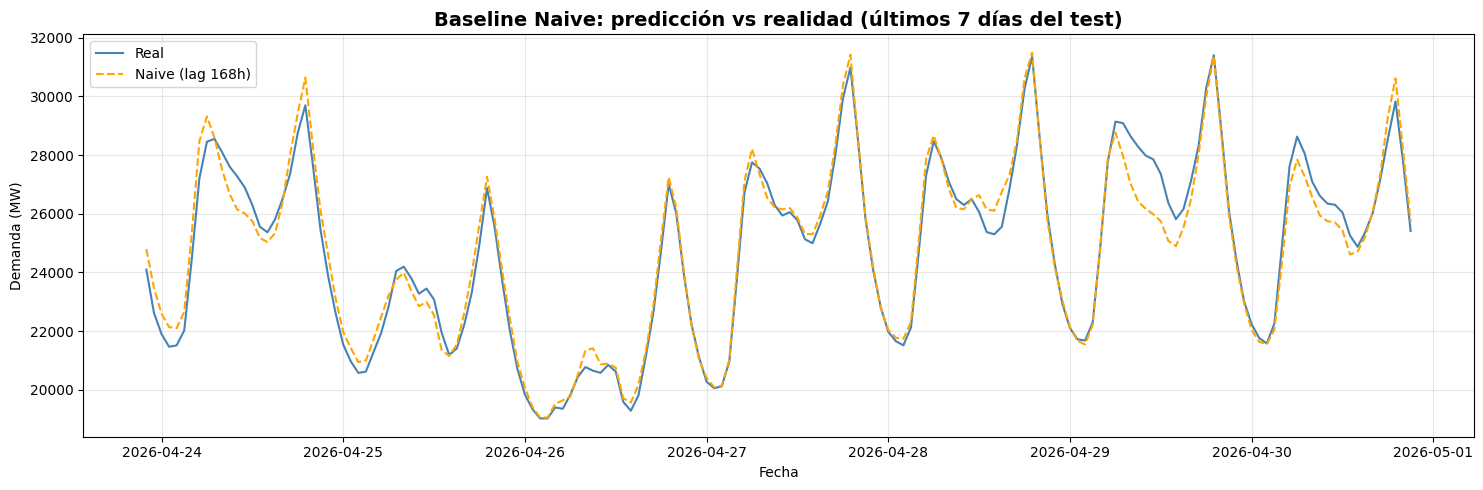

In [6]:
# Plot de los últimos 7 días para ver cualitativamente cómo predice
df_plot = df_eval.tail(168).reset_index()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_plot['timestamp'], df_plot['demanda_mw'], label='Real', color='steelblue', linewidth=1.5)
ax.plot(df_plot['timestamp'], df_plot['pred_naive'], label='Naive (lag 168h)', color='orange', linewidth=1.5, linestyle='--')
ax.set_title('Baseline Naive: predicción vs realidad (últimos 7 días del test)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Demanda (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../docs/capturas/baseline_naive_7d.png', bbox_inches='tight')
plt.show()

In [ ]:
# Guardamos las métricas
import json

resultados_baseline = {
    'modelo': 'naive_estacional_lag168',
    'periodo_test': f"{df_test['timestamp'].min()} → {df_test['timestamp'].max()}",
    'n_predicciones': len(df_eval),
    'metricas': {
        'MAE_MW': round(float(mae), 2),
        'RMSE_MW': round(float(rmse), 2),
        'MAPE_pct': round(float(mape), 2),
    }
}

with open('../resultados_baseline.json', 'w') as f:
    json.dump(resultados_baseline, f, indent=2)

print("✓ Resultados guardados en lstm-local/resultados_baseline.json")
print(f"\nResumen para comparar con LSTM:")
print(json.dumps(resultados_baseline, indent=2))

✓ Resultados guardados en lstm-local/resultados_baseline.json

Resumen para comparar con LSTM:
{
  "modelo": "naive_estacional_lag168",
  "periodo_test": "2026-01-01 00:00:00 \u2192 2026-04-30 21:00:00",
  "n_predicciones": 2878,
  "metricas": {
    "MAE_MW": 1430.42,
    "RMSE_MW": 2332.27,
    "MAPE_pct": 5.11
  }
}
